# Lorenz-96 (single-level) — model, simulation, and observation design

Lorenz-96 is the higher-dimensional sibling of Lorenz-63: a ring of
$K$ coupled scalar variables with periodic boundary conditions,

$$
\frac{dx_k}{dt} = (x_{k+1} - x_{k-2})\,x_{k-1} - x_k + F,
\qquad k = 0, \ldots, K-1.
$$

The same three terms that drove L63 — quadratic non-linearity,
linear damping, constant forcing — show up here on a circular grid.
With the canonical choice $K = 40$, $F = 8$ the system is fully
chaotic and the textbook playground for high-dimensional data
assimilation experiments.

This notebook covers:

1. **Decisions.** $K$, $F$, time-step $dt$, window length $T$.
2. **Simulation.** A long trajectory to verify the chaotic regime
   and to inspect the spatial structure.
3. **Observation design.** Spatial + temporal sparsity. How sparse
   can the obs be before the partial-obs problem becomes
   ill-conditioned without a dynamics constraint?
4. **Missing-data handling.** Why "missing entries set to zero" is
   safe when the mask is symmetric (Decision D14 in the vardax
   design — verified empirically here).

The benchmark itself — all seven `AnalysisStep` methods compared on
this problem — lives in
[`10_lorenz96_benchmark`](10_lorenz96_benchmark.ipynb).

In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from assimilation import Lorenz96Forward, generate_l96_problem

## 1. Decisions

| Parameter | Value | Rationale |
|---|---:|---|
| $K$ | 40 | Canonical chaotic dimension; large enough for spatial structure to matter, small enough to JIT. |
| $F$ | 8.0 | Standard Lorenz "chaotic" forcing. ($F = 4$ is periodic, $F = 16$ is hyper-chaotic.) |
| $dt$ | 0.01 | RK4 integration step; matches L63 for direct timing comparison. |
| $T$ | 20 | 21-step window → 840 trajectory unknowns. Long enough for dynamics to shuffle information, short enough that 4DVar's inner solve is fast. |
| $\sigma_o$ | 1.0 | Obs noise std. The chaotic regime has typical state magnitudes of ~ ±10, so $\sigma_o = 1$ is a roughly $10\%$ noise level. |
| $\sigma_b$ | 5.0 | Background-error std for the diagonal $B$. Generous (effectively "no prior info"). |

## 2. Simulate a long trajectory

We run the L96 forward model for 500 burn-in steps + 500 saved
steps. The first plot is the Hovmöller (time × space) diagram of
the saved trajectory — the moving "blobs" are the chaotic
travelling waves that characterise this system.

In [2]:
fwd_long = Lorenz96Forward(K=40, F=8.0, dt=0.01)
key = jax.random.PRNGKey(0)
x0 = 8.0 * jnp.ones(40) + 0.01 * jax.random.normal(key, (40,))


def _scan(state, _):
    new = fwd_long.step(state, fwd_long.dt)
    return new, new


# Burn-in.
state, _ = jax.lax.scan(_scan, x0, None, length=500)
# Long trajectory.
_, traj_long = jax.lax.scan(_scan, state, None, length=500)
print(f"long trajectory: {traj_long.shape}  (time × space)")
print(f"state range: [{float(traj_long.min()):.2f}, {float(traj_long.max()):.2f}]")
print(f"per-grid-point std: {float(traj_long.std(axis=0).mean()):.2f}")

long trajectory: (500, 40)  (time × space)
state range: [-7.27, 11.44]


per-grid-point std: 3.36


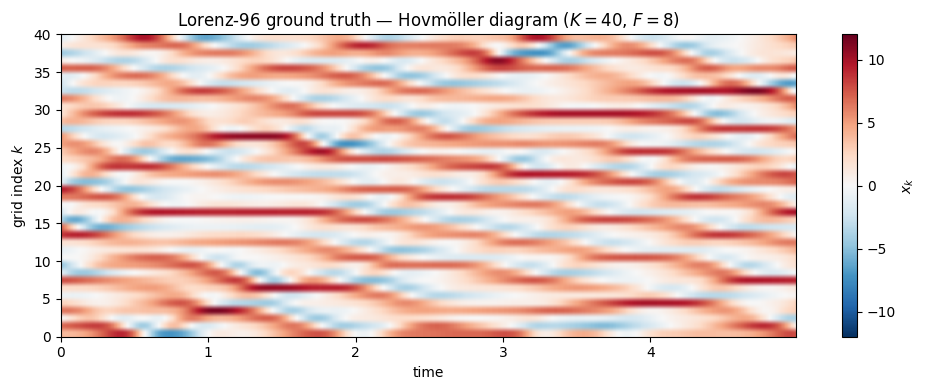

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
t = jnp.arange(500) * 0.01
im = ax.imshow(
    traj_long.T,
    aspect="auto",
    cmap="RdBu_r",
    origin="lower",
    extent=(0, float(t[-1]), 0, 40),
    vmin=-12,
    vmax=12,
)
ax.set_xlabel("time")
ax.set_ylabel("grid index $k$")
ax.set_title("Lorenz-96 ground truth — Hovmöller diagram ($K=40$, $F=8$)")
fig.colorbar(im, ax=ax, label="$x_k$")
fig.tight_layout()
plt.show()

Travelling-wave structure with $\sim 8$ active sites at any moment,
moving in the $+k$ direction. That's the system's spatial coherence
scale — and it's exactly the scale our observations must capture.

## 3. Observation design

The benchmark problem masks the truth in **both space and time**:

- *Spatial mask*: keep every `obs_every_space`-th grid point.
- *Temporal mask*: keep every `obs_every_time`-th time step.

The combined mask is the outer product of the two. With default
strides of 4 in each, we observe $10 \times 6 = 60$ scalars out of
the $21 \times 40 = 840$-entry trajectory — about $7\%$ coverage.

In [4]:
prob = generate_l96_problem(key=jax.random.PRNGKey(0))
print(f"problem: K={prob.K}, T+1={prob.T_plus_1}")
print(f"obs coverage: {int(prob.mask.sum())} / {prob.mask.size} = "
      f"{prob.mask.sum() / prob.mask.size:.1%}")

problem: K=40, T+1=21
obs coverage: 60 / 840 = 7.1%


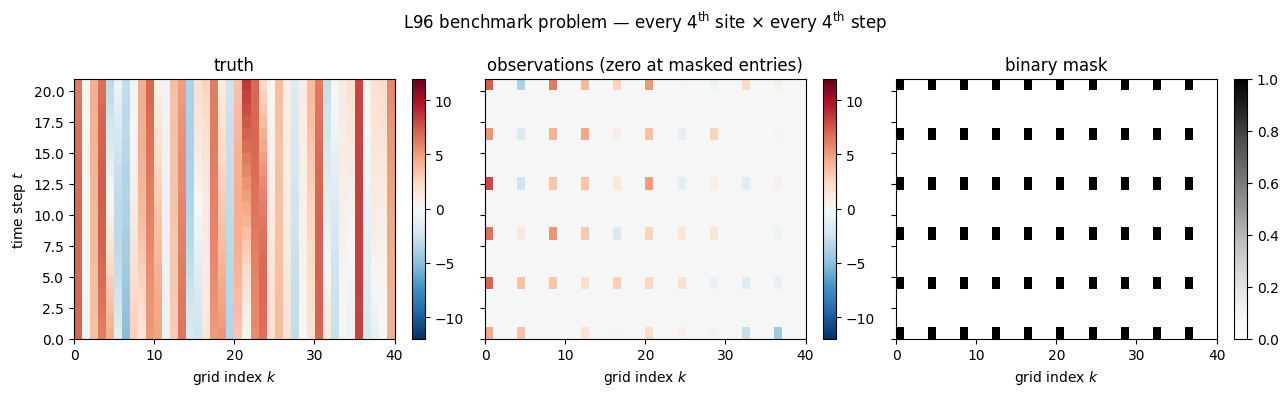

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
extent = (0, prob.K, 0, prob.T_plus_1)
for ax, field, title, cmap in zip(
    axs,
    [prob.truth, prob.obs, prob.mask],
    ["truth", "observations (zero at masked entries)", "binary mask"],
    ["RdBu_r", "RdBu_r", "Greys"],
    strict=False,
):
    im = ax.imshow(field, aspect="auto", cmap=cmap, origin="lower", extent=extent,
                   vmin=-12 if cmap == "RdBu_r" else None,
                   vmax=12 if cmap == "RdBu_r" else None)
    ax.set_xlabel("grid index $k$")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.04)
axs[0].set_ylabel("time step $t$")
fig.suptitle("L96 benchmark problem — every $4^\\text{th}$ site × every $4^\\text{th}$ step")
fig.tight_layout()
plt.show()

## 4. How sparse can we go before OI / 3DVar collapse?

Because the default $B$ is diagonal (no time- or space-coupling),
OI / 3DVar can only update *observed* entries. The expected RMSE is
therefore the std of the *unobserved* truth — i.e. the prior std
under the model.

Let's measure: simulate a long L96 trajectory, take the per-cell
std, and compare with the all-zero-prior RMSE that OI achieves on
the masked entries.

In [6]:
prior_rmse_unobs = float(
    jnp.sqrt(jnp.mean((prob.truth * (1 - prob.mask)) ** 2))
)
prior_rmse_total = float(jnp.sqrt(jnp.mean(prob.truth**2)))
print(f"RMSE of zero-prior on unobserved entries: {prior_rmse_unobs:.2f}")
print(f"RMSE of zero-prior on whole trajectory:   {prior_rmse_total:.2f}")

RMSE of zero-prior on unobserved entries: 3.82
RMSE of zero-prior on whole trajectory:   3.91


That `prior_rmse_total` (~4) is the OI / 3DVar floor for this
problem. To do meaningfully better, the analysis needs to *propagate*
information from observed grid points into unobserved ones — and the
only mechanism for that is the **dynamics**. That's the entire
motivation for the rest of the benchmark notebook.

## 5. Why "missing entries set to zero" is safe

vardax represents observations as a dense `(T+1, K)` array with
zeros at masked entries — not NaN, not a sparse representation.
This relies on a **symmetric-masking invariant** in the cost
function:

$$
J_\text{obs} = \tfrac{1}{2} \sum_t \|m_t \odot (y_t - H x_t)\|^2_{R^{-1}}.
$$

As long as the mask is applied **on both sides of the residual**
(and `obs_op(x)` doesn't peek at masked entries), the zero-padding
carries no information — it's purely a storage convention.

vardax v0.4 enforces this invariant across all six iterative
methods (see [`vardax`/tests/test_masked_residual_regression.py](https://github.com/jejjohnson/vardax/blob/main/tests/test_masked_residual_regression.py)).
For the operational `LinearObs(H=I)` we use here it just works.

## 6. Sanity check — round-trip the forward

Confirm that `Lorenz96Forward.step` re-integrates the truth's
initial state to within machine precision (so the strong-4DVar
perfect-model assumption is actually true at the integration
resolution we picked).

In [7]:
fwd = Lorenz96Forward(K=prob.K, F=prob.F, dt=prob.dt)


def rollout(x0_):
    def step(s, _):
        new = fwd.step(s, fwd.dt)
        return new, new
    _, traj = jax.lax.scan(step, x0_, None, length=prob.T)
    return jnp.concatenate([x0_[None, :], traj], axis=0)


truth_roundtrip = rollout(prob.truth[0])
print(f"roundtrip max abs error: {float(jnp.max(jnp.abs(truth_roundtrip - prob.truth))):.2e}")
print("(Should be ~0 to machine precision.)")

roundtrip max abs error: 0.00e+00
(Should be ~0 to machine precision.)


## 7. Next

All the pieces are in place: a problem object that bundles the
truth, observations, mask, and operators; a forward model that
round-trips the truth; a sparse-and-noisy observation pattern that
leaves room for the dynamics constraint to add signal.

Continue to [`10_lorenz96_benchmark`](10_lorenz96_benchmark.ipynb)
to see how each of the seven `AnalysisStep` methods handles it.